# Statistical downscaling Tasmax and Tasmin (and DTR)

In [1]:
from glob import glob
from pathlib import Path
from os.path import basename
import zipfile
import matplotlib.pyplot as plt

#Librairies for working with multi-dimensional arrays
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr #Opening netcdf files as datasets and dataArrays
import pandas as pd
import os

In [ ]:
#Libraries for working with climate data
#Projecting the files
import cartopy.crs as ccrs  # projection
import rioxarray
import rasterio

import xesmf as xe    #For regridding climate data

In [3]:
# Cliping netcdf file

from shapely.geometry import mapping
import geopandas as gpd  #for reading the shapefile
import regionmask  #For masking dataset


In [4]:
#Xclim module
import xclim as xc
from xclim import sdba

from xclim import ensembles

In [5]:
#Let import the models needed
from cmethods import CMethods as cm

#Libaray  suite of correlation-based and distance-based deterministic metrics:
import xskillscore as xs

In [6]:
#Finland Shape file
shapefile = r"C:\Christine\DEM\FIN_adm\FIN_adm0.shp"
shp_fin= gpd.read_file(shapefile)  # reading shapefile with geopandas


<Axes: >

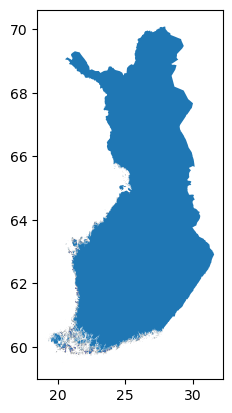

In [7]:
#Finland Shape file
shapefile = r"C:\Users\cnakigud23\Downloads\finland\Finland shapefile.shp"
shp_fin= gpd.read_file(shapefile)  # reading shapefile with geopandas

# from polar coordinates to degrees lon and lat
shp_fin= shp_fin.to_crs("EPSG: 4326")
shp_fin.plot()


In [7]:
def input_prep(cm):
    #Normalize the dates
    cm['time']= cm.indexes['time'].normalize()
    return cm

def calendar(ds):
    ds = xc.core.calendar.convert_calendar(ds,'noleap')
    return ds

def change_calendar(cm): #changes dates from object to datetime
    datetimeindex = cm.indexes['time'].to_datetimeindex()
    cm['time'] = datetimeindex
    return cm

    
def units_conv(cm):    
    #Changing units from Kelvins to degrees celcuis
    cm['tasmax'] = cm['tasmax']-273.15
    cm['tasmax'].attrs['units'] = 'degC' #'degree celcius'
    cm['lat'].attrs['units'] ='degrees north '
    cm['lon'].attrs['units'] ='degrees east'
    
    return cm
    

#Regridding

def coarse_fine(coarse_nc, fine_nc):
    regridder= xe.Regridder(coarse_nc, fine_nc, 'bilinear',unmapped_to_nan=True)
    cm_ds=regridder(coarse_nc, skipna=True, na_thres=.01, keep_attrs= True)
    return cm_ds

def fine_coarse1(fine_nc, coarse_nc):
    #regridder= xe.Regridder(fine_nc, coarse_nc, 'bilinear',extrap_method= 'nearest_s2d',unmapped_to_nan=True)
    
    regridder= xe.Regridder(fine_nc, coarse_nc, 'conservative',unmapped_to_nan=True)#
    cm1= regridder(fine_nc, skipna=True, na_thres=.01, keep_attrs= True)
    return cm1



def spatial_aggregation(cm, cm_cmip6):
    cm_ext= cm.interp_like(ds_out2)  #Extending the grids (from irregular grid to rectangualar grid)

    cm_ff1=  cm_ext.ffill(dim='lat')  # filling the new grids
    cm_ff2=  cm_ff1.ffill(dim='lon')

    cm_ff=  cm_ff2.bfill(dim='lat')
    
    cm_agg= fine_coarse1(cm_ff.tasmax, cm_pr_2014.tasmax)
    
    #cm_agg= fine_coarse1(cm_ff, cm_pr_2014)
    return cm_agg


#Tas and Detrending
def tas_detrended_qdm(obs, simh, simp):
    obs= xc.core.calendar.convert_calendar(obs, "noleap")
    simh= xc.core.calendar.convert_calendar(simh, "noleap")
    simp= xc.core.calendar.convert_calendar(simp, "noleap")
    
    
    ref= obs['tasmax']
    hist= simh['tasmax']
    sim= simp['tasmax']
    
    #Deleting experiment ccordinate from the dataset
    #hist= hist.reset_coords(names="experiment", drop=True)
    #sim= sim.reset_coords(names="experiment", drop=True)
    
    doy_win31 = sdba.Grouper("time.dayofyear", window=15)
    Sca = sdba.Scaling.train(ref, hist, group=doy_win31, kind="+")
    sim_scl = Sca.adjust(sim)

    detrender = sdba.detrending.PolyDetrend(degree=1, group="time.dayofyear", kind="+")
    sim_fit = detrender.fit(sim_scl)
    sim_detrended = sim_fit.detrend(sim_scl)

    ref_n, _ = sdba.processing.normalize(ref, group=doy_win31, kind="+")
    hist_n, _ = sdba.processing.normalize(hist, group=doy_win31, kind="+")

    QM = sdba.QuantileDeltaMapping.train(
        ref_n, hist_n, nquantiles=20, group="time.month", kind="+"
    )
    scen_detrended = QM.adjust(sim_detrended, extrapolation="constant", interp="linear")
    scen = sim_fit.retrend(scen_detrended)
    
    cm_bc=simp.copy()
    cm_bc['tasmax'] = scen
    return cm_bc    
    
    


def clip_fin(cm, shp):
    cm = cm.rename({'lat':'y', 'lon':'x'}) # Specifiying the coordinate system
    cm.rio.write_crs("EPSG:4326",inplace= True)
    
    cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs, all_touched= True, drop= True)
    #cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs)
    
    cm_fin= cm_fin.rename({'y':'lat', 'x':'lon'})
    return cm_fin


#Assessing performance of model against observed data
def coeff_determ(ref, bc):
    #Using Coeffecient of determination
    R2= xs.r2(ref.tasmax, bc.tasmax, dim='time', skipna=True, keep_attrs=True)

    #converting to array
    R2_arr= np.array(R2)
    r2= np.nanmean(R2_arr)
    return r2

   
def mean_absolute_error(ref, bc):
    MAE= xs.mae(ref.tasmax, bc.tasmax, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    MAE_arr= np.array(MAE)
    mae= np.nanmean(MAE_arr)
    return mae 

def pearson_correlation(ref, bc):
    R= xs.pearson_r(ref.tasmax, bc.tasmax, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    r_arr= np.array(R)
    r= np.nanmean(r_arr)
    return r


def standard_deviation(ref):
    st_dev= ref.std(skipna=True)
    #converting to array
    std_arr= np.nanmean(st_dev.tasmax)
    
    return std_arr 

def root_mean_square_error(ref, bc):
    RMSE= xs.rmse(ref.tasmax, bc.tasmax, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    rmse_arr= np.array(RMSE)
    rmse= np.nanmean(rmse_arr)
    return rmse




In [8]:
def ens_period(cm, start, end):
    cm_period= cm.tas[1:5].sel(time= slice(start, end))
    return cm_period

def spatial_agg(cm):
    weights = np.cos(np.deg2rad(cm.lat))
    weights.name= 'weights'
    cm_weighted= cm.weighted(weights)
    cm_agg = cm_weighted.mean(['lat','lon'])
    
    return cm_agg

def groupby_season(cm):
    
    cm_season_mean= cm.groupby('time.season').mean('time',skipna=False).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    cm_season_mean.attrs['units'] ='degC'
    return cm_season_mean


def groupby_day(cm):
    cm_day= cm.groupby('time.dayofyear').mean('time',skipna=False)
    cm_day.attrs['units'] ='degC'
    return cm_day


def groupby_month(cm):
   
    cm_month_mean= cm.groupby('time.month').mean('time',skipna=False)
    cm_month_mean.attrs['units'] ='degC'
    return cm_month_mean

def groupby_year(cm):
    cm_yr= cm.groupby('time.year').mean('time',skipna=False)
    cm_yr.attrs['units'] ='degC'
    return cm_yr

def anomly(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='degC'

    return cm_change 

def anomly_day(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='degC'

    return cm_change 

In [9]:
def DTR(ds_max, ds_min):
    dr_dtr= ds_max.tasmax-ds_min.tasmin
    
    dr_dtr.attrs['units'] ='degC'
    dr_dtr.attrs['long_name'] ='Daily temperature range'
    
    
    ds_dtr= dr_dtr.to_dataset(name='DTR')
    
    
    return ds_dtr

In [ ]:
#reading observed gridded data for Finland
#reading observed gridded data for Finland
cm_obs_max = xr.open_dataset(r"C:\Christine\Hydrology\Gridded data Observed Finland\Obs_Fin\tasmax_latlon.nc")

cm_obs_max= cm_obs_max.rename({'tmax':'tasmax'})

cm_obs_max= cm_obs_max.reset_coords(names="spatial_ref", drop=True)


#Daily minimum temperature
cm_obs_min = xr.open_dataset(r"C:\Christine\Hydrology\Gridded data Observed Finland\Obs_Fin\Tmin_latlon.nc")

cm_obs_min= cm_obs_min.rename({'tmin':'tasmin'})
cm_obs_min= cm_obs_min.reset_coords(names="spatial_ref", drop=True)


cm_obs_min

In [ ]:
DTR_dr= DTR(cm_obs_max, cm_obs_min)
DTR_dr

In [12]:
#Clipping to the shapefile of Finland
cm_obs_fin_max = clip_fin(cm_obs_max, shp_fin)

cm_obs_fin_dtr= clip_fin(DTR_dr, shp_fin)

In [10]:
#Regridder to 1 x 1 degree
ds_out1 = xr.Dataset(
    {
        "lat": (["lat"], np.arange(cm_obs_fin.lat[-1], cm_obs_fin.lat[0]+1, 1), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(cm_obs_fin.lon[0],cm_obs_fin.lon[-1]+1, 1), {"units": "degrees_east"}),
    }
)


In [9]:
#Regridder to 1 x 1 degree
ds_out = xr.Dataset(
    {
        "lat": (["lat"], np.arange(59, 71, 1.0), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(20, 32, 1.0), {"units": "degrees_east"}),
    }
)

In [ ]:
plt.figure()
ax= plt.axes()
cm_obs_fin_max['tasmax'][215].plot.pcolormesh(ax=ax, cmap='Blues')
shp_fin.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

# Part 1. Bias correcting GCM Models Tasmax

### Oulujoki

<Axes: >

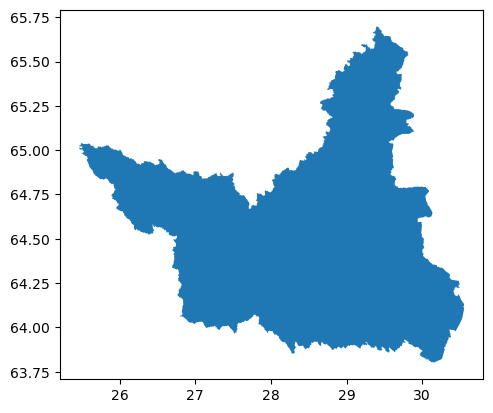

In [13]:
#Reading oulu shapefile
# Reading the shape file
shapefile2 = r"C:\Christine\DEM\ArcMAP\Oulujoki_cat.shp"
shp_oul2= gpd.read_file(shapefile2)  # reading shapefile with geopandas

# from polar coordinates to degrees lon and lat
shp_oul= shp_oul2.to_crs("EPSG: 4326")
shp_oul.plot()

In [14]:
#Clipping to the shapefile of Oulujoki
cm_obs_oul_max = clip_fin(cm_obs_max, shp_oul)

cm_obs_oul_dtr= clip_fin(DTR_dr, shp_oul)

In [15]:
#Directory to read historical data


DATADIR= r"D:\GCM\AWI-CM-1-1-MR\Historical\tasmax_day*.nc"
path= glob(f'{DATADIR}')

In [18]:
#Directory to read model data
DATADIR2= r"D:\GCM\AWI-CM-1-1-MR\*SSP*\tasmax_day*.nc"
path2= glob(f'{DATADIR2}')

In [21]:
#Directory to store the data

#DATADIR3= r"D:\GCM\MIROC6\Bias corrected sdbc/"
DATADIR3= r"D:\GCM\AWI-CM-1-1-MR\Bias corrected sdbc\Oul/"

In [ ]:
for file in path:
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    mod = cm_hist.attrs['source_id']
    var= cm_hist.attrs['variable_id']
    
    #changing dates from cft date time to datetime    
    #datetimeindex = cm_hist.indexes['time'].to_datetimeindex()
    #cm_hist['time']=datetimeindex

    #Changing the date format ( can be skipped if not needed)
    cm_hist= cm_hist.sel(time=~((cm_hist.time.dt.month == 2) & (cm_hist.time.dt.day == 29)))
    cm_hist= input_prep(cm_hist)
    
    #Dropping variables
    cm_hist= cm_hist.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
    #cm_hist= cm_hist.drop_vars(["time_bounds"])
    

    #converting units
    cm_hist= units_conv(cm_hist)

    #Regridding data to 1x1 grid
    cm_hist_ds= coarse_fine(cm_hist, cm_obs_max)
    
    #Clipping to finland
    #cm_hist_fin = clip_fin(cm_hist_ds, shp_fin)
    
    #Bias correction of historical data
    #cm_bc_c= tas_detrended_qdm(cm_obs_fin_max, cm_hist_fin,cm_hist_fin)
    
    #Clipping to Oulujoki
    cm_hist_fin = clip_fin(cm_hist_ds, shp_oul)
    
    #Bias correction of historical data
    
    
    cm_bc_c= tas_detrended_qdm(cm_obs_oul_max, cm_hist_fin,cm_hist_fin)
    
    
    #cm_bc_c= cm_bc_c.transpose('time','lat','lon','bnds')
    cm_bc_c= cm_bc_c.transpose('time','lat','lon')
    
    
    #Changing calendars
    cm_bc_c= change_calendar(cm_bc_c)

    cm_bc_c.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
     
    print('worked on historical file')

for file in path2:

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        mod = cm_raw.attrs['source_id']
        var= cm_raw.attrs['variable_id']
        
        #changing dates from cft date time to datetime    
        #datetimeindex = cm_raw.indexes['time'].to_datetimeindex()
        #cm_raw['time']=datetimeindex
        
        #Changing the date format ( can be skipped if not needed)
        
        cm_raw= cm_raw.sel(time=~((cm_raw.time.dt.month == 2) & (cm_raw.time.dt.day == 29)))
              
        cm_raw= input_prep(cm_raw)
        
        
        #Dropping variables
        cm_raw= cm_raw.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
        #cm_raw= cm_raw.drop_vars(["time_bounds"]) # CNRM_CM6-1, IPSL-CM6A-LR

        #converting units
        cm_raw= units_conv(cm_raw)

        #Regridding data to 1x1 grid
        
        cm_raw_ds= coarse_fine(cm_raw, cm_obs_max)
        
        #Clipping to finland
        #cm_raw_fin = clip_fin(cm_raw_ds, shp_fin)
               
        #bias correction
        #cm_bc_f= tas_detrended_qdm(cm_obs_fin_max, cm_hist_fin, cm_raw_fin)
        
        
        #Clipping to Oulujoki
        cm_raw_fin = clip_fin(cm_raw_ds, shp_oul)
               
        #bias correction
        cm_bc_f= tas_detrended_qdm(cm_obs_oul_max, cm_hist_fin, cm_raw_fin)
        
        
        #cm_bc_f= cm_bc_f.transpose('time','lat','lon','bnds')
        cm_bc_f= cm_bc_f.transpose('time','lat','lon')
        
        #Changing calendar back
        cm_bc_f= change_calendar(cm_bc_f)
        
        
        #Exporting file
        cm_bc_f.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

### Model Performace against Oberved data

In [23]:
#cm_obs_fin_2014= cm_obs_fin_max.sel(time=slice(None, '2014-12-31'))

cm_obs_fin_2014= cm_obs_oul_max.sel(time=slice(None, '2014-12-31'))
#Grouping by month

cm_obs_fin_m = cm_obs_fin_2014.resample(time='M').mean(dim='time', skipna=False)

In [24]:
sd_obs= cm_obs_fin_m.std(skipna= True)
sd= np.nanmean(sd_obs.tasmax)
print(sd)

10.246148109436035


In [25]:
cm_bc_hist_fin_m = cm_bc_c.resample(time='M').mean(dim='time', skipna=False)

cm_hist_m = cm_hist_fin.resample(time='M').mean(dim='time', skipna=False)

In [ ]:
#Evalution of methods
 #Person Correlation
print(f'The cofficient of correlation before bias correcction of model {mod} is {pearson_correlation(cm_obs_fin_m, cm_hist_m)}')    
print(f'The cofficient of correlation after  bias correcction of model {mod} is {pearson_correlation(cm_obs_fin_m, cm_bc_hist_fin_m)}')


#Absolute mean error.
print(f'The mean Absolute error before  bias correction of model {mod} is {mean_absolute_error(cm_obs_fin_m, cm_hist_m)}')

print(f'The mean Absolute error after  bias correction of model {mod} is {mean_absolute_error(cm_obs_fin_m, cm_bc_hist_fin_m)}')

# Standard deviation
print(f'The Standard devaiation before bias correction of model {mod} is {standard_deviation(cm_hist_m)}')
print(f'The Standard devaiation after bias correction of model {mod} is {standard_deviation(cm_bc_hist_fin_m)}')


print(f'The root_mean_square_error before bias correction of model {mod} is {root_mean_square_error(cm_obs_fin_m, cm_hist_m)}')
print(f'The root_mean_square_error after bias correction of model {mod} is {root_mean_square_error(cm_obs_fin_m, cm_bc_hist_fin_m)}')


In [ ]:
Ensemble Performance

# Part 2 Statistical downscaling and Bias correction DTR 

In [28]:
#Directory to read historical data
# read historical model files

# reading Tasmax
DATADIR5= r"D:\GCM\AWI-CM-1-1-MR\Historical\tasmax*.nc"
path5= glob(f'{DATADIR5}')

#Reading Tas min
DATADIR6= r"D:\GCM\AWI-CM-1-1-MR\Historical\tasmin*.nc"
path6= glob(f'{DATADIR6}')



In [34]:
#Directory to read model data
DATADIR7= r"D:\GCM\AWI-CM-1-1-MR\SSP126\tasmax*.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\GCM\AWI-CM-1-1-MR\SSP126\tasmin*.nc"
path8= glob(f'{DATADIR8}')


In [30]:
for file in path5:
    print(file)
for file in path6:
    print(file)

for file in path7:
    print(file)
    
for file in path8:
    print(file)

D:\GCM\AWI-CM-1-1-MR\Historical\tasmax_day_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_19800101-20141231_v20181218.nc
D:\GCM\AWI-CM-1-1-MR\Historical\tasmin_day_AWI-CM-1-1-MR_historical_r1i1p1f1_gn_19800101-20141231_v20181218.nc
D:\GCM\AWI-CM-1-1-MR\SSP126\tasmax_day_AWI-CM-1-1-MR_ssp126_r1i1p1f1_gn_20150101-21001231_v20190529.nc
D:\GCM\AWI-CM-1-1-MR\SSP126\tasmin_day_AWI-CM-1-1-MR_ssp126_r1i1p1f1_gn_20150101-21001231_v20190529.nc


In [31]:
def DTR(ds_max, ds_min):
    dr_dtr= ds_max.tasmax-ds_min.tasmin
    
    dr_dtr.attrs['units'] ='degC'
    dr_dtr.attrs['long_name'] ='Daily temperature range'
    
    
    ds_dtr= dr_dtr.to_dataset(name='DTR')
    
    
    return ds_dtr

In [32]:
def units_conv_tasmin(cm):    
    #Changing units from Kelvins to degrees celcuis
    cm['tasmin'] = cm['tasmin']-273.15
    cm['tasmin'].attrs['units'] = 'degC' #'degree celcius'
    cm['lat'].attrs['units'] ='degrees north '
    cm['lon'].attrs['units'] ='degrees east'
    
    return cm

#Tas and Detrending
def tas_detrended_qdm_dtr(obs, simh, simp):
    obs= xc.core.calendar.convert_calendar(obs, "noleap")
    simh= xc.core.calendar.convert_calendar(simh, "noleap")
    simp= xc.core.calendar.convert_calendar(simp, "noleap")
    
    
    ref= obs['DTR']
    hist= simh['DTR']
    sim= simp['DTR']
    
    #Deleting experiment ccordinate from the dataset
    #hist= hist.reset_coords(names="experiment", drop=True)
    #sim= sim.reset_coords(names="experiment", drop=True)
    
    doy_win31 = sdba.Grouper("time.dayofyear", window=15)
    Sca = sdba.Scaling.train(ref, hist, group=doy_win31, kind="+")
    sim_scl = Sca.adjust(sim)

    detrender = sdba.detrending.PolyDetrend(degree=1, group="time.dayofyear", kind="+")
    sim_fit = detrender.fit(sim_scl)
    sim_detrended = sim_fit.detrend(sim_scl)

    ref_n, _ = sdba.processing.normalize(ref, group=doy_win31, kind="+")
    hist_n, _ = sdba.processing.normalize(hist, group=doy_win31, kind="+")

    QM = sdba.QuantileDeltaMapping.train(
        ref_n, hist_n, nquantiles=20, group="time.month", kind="+"
    )
    scen_detrended = QM.adjust(sim_detrended, extrapolation="constant", interp="linear")
    scen = sim_fit.retrend(scen_detrended)
    
    cm_bc=simp.copy()
    cm_bc['DTR'] = scen
    return cm_bc   

#### For the historical period

In [ ]:
for file in path5:

    cm_tasmax= xr.open_dataset(file)
    
    #Getting attibutes
    exp= cm_tasmax.attrs['experiment_id']
    mod = cm_tasmax.attrs['source_id']
    #converting units
    cm_tasmax= units_conv(cm_tasmax)
    
for file in path6:
    
    cm_tasmin= xr.open_dataset(file)
    #converting units
    cm_tasmin= units_conv_tasmin(cm_tasmin)
    
    try:
    
        cm_dtr= DTR(cm_tasmax, cm_tasmin)

        #changing dates from cft date time to datetime    
        #datetimeindex = cm_dtr.indexes['time'].to_datetimeindex()
        #cm_dtr['time']=datetimeindex



        #Changing the date format (can be skipped if not needed)
        cm_dtr= cm_dtr.sel(time=~((cm_dtr.time.dt.month == 2) & (cm_dtr.time.dt.day == 29)))

        cm_dtr= input_prep(cm_dtr)
        
        
        #Regridding data to 1x1 grid
        cm_hist_ds= coarse_fine(cm_dtr, cm_obs_max)

        #Clipping to finland
        #cm_hist_fin = clip_fin(cm_hist_ds, shp_fin)

        #Bias correction of historical data
        #cm_bc_c= tas_detrended_qdm_dtr(cm_obs_fin_dtr, cm_hist_fin,cm_hist_fin)
        
        
        
        #Clipping to Oulujoki
        cm_hist_fin = clip_fin(cm_hist_ds, shp_oul)

        #Bias correction of historical data
        cm_bc_c= tas_detrended_qdm_dtr(cm_obs_oul_dtr, cm_hist_fin,cm_hist_fin)
        
        
        
        cm_bc_c.attrs['experiment_id']= exp
        cm_bc_c.attrs['source_id']= mod
        cm_bc_c.attrs['variable_id']= 'dtr'


        #cm_bc_c= cm_bc_c.transpose('time','lat','lon','bnds')
        cm_bc_c= cm_bc_c.transpose('time','lat','lon')


        #Changing calendars
        cm_bc_c= change_calendar(cm_bc_c)
        cm_bc_c.to_netcdf(f'{DATADIR3}dtr_{mod}_{exp}.nc')
        
        print(f'dtr_{mod}_{exp} has been exported')
        
    except Exception as err:
        print(err)

In [40]:
#Directory to read model data
DATADIR7= r"D:\GCM\AWI-CM-1-1-MR\SSP585\tasmax*.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\GCM\AWI-CM-1-1-MR\SSP585\tasmin*.nc"
path8= glob(f'{DATADIR8}')

### For SSP scenarios

In [ ]:
for file in path7:

    cm_tasmax= xr.open_dataset(file)
    
    #Getting attibutes
    exp= cm_tasmax.attrs['experiment_id']
    mod = cm_tasmax.attrs['source_id']
    #converting units
    cm_tasmax= units_conv(cm_tasmax)
    
for file in path8:
    
    cm_tasmin= xr.open_dataset(file)
    #converting units
    cm_tasmin= units_conv_tasmin(cm_tasmin)
    
    try:
    
        cm_raw_dtr= DTR(cm_tasmax, cm_tasmin)

        #changing dates from cft date time to datetime    
        #datetimeindex = cm_raw_dtr.indexes['time'].to_datetimeindex()
        #cm_raw_dtr['time']=datetimeindex



        #Changing the date format (can be skipped if not needed)
        cm_raw_dtr= cm_raw_dtr.sel(time=~((cm_raw_dtr.time.dt.month == 2) & (cm_raw_dtr.time.dt.day == 29)))

        cm_raw_dtr= input_prep(cm_raw_dtr)
        
        
        #Regridding data to 1x1 grid
        cm_raw_ds= coarse_fine(cm_raw_dtr, cm_obs_max)

        #Clipping to finland
        #cm_raw_fin = clip_fin(cm_raw_ds, shp_fin)
        

        #Bias correction of historical data
        #cm_bc_f= tas_detrended_qdm_dtr(cm_obs_fin_dtr, cm_hist_fin,cm_raw_fin)
        
        
        #Clipping to finland
        cm_raw_fin = clip_fin(cm_raw_ds, shp_oul)
        

        #Bias correction of historical data
        cm_bc_f= tas_detrended_qdm_dtr(cm_obs_oul_dtr, cm_hist_fin,cm_raw_fin)
        
                        
        cm_bc_f.attrs['experiment_id']= exp
        cm_bc_f.attrs['source_id']= mod
        cm_bc_f.attrs['variable_id']= 'dtr'


        #cm_bc_c= cm_bc_c.transpose('time','lat','lon','bnds')
        cm_bc_f= cm_bc_f.transpose('time','lat','lon')


        #Changing calendars
        cm_bc_f= change_calendar(cm_bc_f)
        cm_bc_f.to_netcdf(f'{DATADIR3}dtr_{mod}_{exp}.nc')
        
        print(f'dtr_{mod}_{exp} has been exported')
        
    except Exception as err:
        print(err)
    
    


In [ ]:
plt.figure()
ax= plt.axes()
cm_bc_f.DTR[26590].plot.pcolormesh(ax=ax)
shp_oul.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

## Creating Bias corrected Tasmin
### Individual GCMs

In [44]:
def tasmin_bc(ds_max, ds_dtr):
    dr_tasmin= ds_max.tasmax-ds_dtr.DTR
    
    dr_tasmin.attrs['units'] ='degC'
        
    dr_tasmin.attrs['long_name'] ='Daily minimum temperature'
    
    dr_tasmin.attrs['bias_adjustment'] ="QuantileDeltaMapping(group=Grouper(name='time.month'), kind='+').adjust(sim, extrapolation='constant', interp='linear')"
    
    
    ds_tasmin= dr_tasmin.to_dataset(name='tasmin')
    
    ds_tasmin.attrs['experiment_id']= exp
    ds_tasmin.attrs['source_id']= mod
    ds_tasmin.attrs['variable_id']= 'tasmin'
    
    
    return ds_tasmin

In [61]:
#DATADIR3= r"D:\GCM\ACCESS_CM2\Bias corrected sdbc/"


DATADIR3= r"D:\GCM\AWI-CM-1-1-MR\Bias corrected sdbc\Oul/"

path3= glob(f'{DATADIR3}dtr*ssp585*.nc')

path4 = glob(f'{DATADIR3}tasmax*ssp585*.nc')

In [62]:
for file in path3:
    print(file)

D:\GCM\AWI-CM-1-1-MR\Bias corrected sdbc\Oul\dtr_AWI-CM-1-1-MR_ssp585.nc


In [63]:
for file in path4:
    print(file)

D:\GCM\AWI-CM-1-1-MR\Bias corrected sdbc\Oul\tasmax_AWI-CM-1-1-MR_ssp585.nc


In [64]:
for file in path4:
    cm_tasmax= xr.open_dataset(file)
    
    #Getting attributes
    
    exp= cm_tasmax.attrs['experiment_id']
    mod = cm_tasmax.attrs['source_id']
    
    
for file in path3:
    cm_dtr= xr.open_dataset(file)
    
try:
    cm_tasmin= tasmin_bc(cm_tasmax,cm_dtr)
    
    cm_tasmin.to_netcdf(f'{DATADIR3}tasmin_{mod}_{exp}.nc')
        
    print(f'tasmin_{mod}_{exp} has been exported')
        
except Exception as err:
    print(err)

tasmin_AWI-CM-1-1-MR_ssp585 has been exported


In [ ]:
plt.figure()
ax= plt.axes()
cm_tasmin.tasmin[10890].plot.pcolormesh(ax=ax)
shp_oul.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

## Ensemble Tasmax for Oulujoki

In [22]:
DATADIR7= r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmax BCSD\tasmax*ssp*.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmax BCSD\tasmax*hist*.nc"
path8= glob(f'{DATADIR8}')

In [23]:
#Directory to bias corrected scenarios

DATADIR9= r"D:\Oulujoki\BC\Tasmax BCSD/"
path9 =glob(f'{DATADIR9}tasmax*ssp*.nc')

In [78]:
#Oulujoki Extents

min_lon = 25.46004795
max_lon = 30.55364291
min_lat = 63.00
max_lat = 65.69757354

#rectangular clipping 
cm_hist2 =cm_hist.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))

In [ ]:
for file in path8:
    cm_hist= xr.open_dataset(file, decode_coords='all' )
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    var= cm_hist.attrs['variable_id']
    mod = cm_hist.attrs['source_id']
        
    cm_hist = cm_hist.sel(time=slice(None, '2014-12-31'))

    #Clipping to finland
    cm_hist_oul = clip_fin(cm_hist, shp_oul)
    cm_hist_oul['tasmax'].attrs['units'] ='degC'
    
    cm_hist_oul.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
   
    print('worked on historical file')
    
    
for file in path7:

    cm_raw=  xr.open_dataset(file, decode_coords='all')
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        var= cm_raw.attrs['variable_id']
        mod = cm_raw.attrs['source_id']
        
        cm_raw = cm_raw.sel(time=slice('2015-01-01', None))
                       
        #Clipping to Oulu
        cm_raw_oul = clip_fin(cm_raw, shp_oul)
        
        cm_raw_oul['tasmax'].attrs['units'] ='degC'

        #Exporting file
        cm_raw_oul.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

In [83]:
 _, index = np.unique(cm_raw['time'], return_index=True)
index
tt = cm_raw.sel(time=~cm_raw.get_index("time").duplicated())
tt

array([    0,     3,     4, ..., 62774, 62777, 62778], dtype=int64)

In [9]:
#cmip6_ens= xr.open_dataset(r"C:\Christine\Hydrology\Downscale\Finland\cmip6_model_ens_tasday.nc")

## Model Performance raw

In [11]:
cm_obs_2014 = cm_obs_fin.sel(time=slice(None,'2014-12-31'))

In [12]:
cm_obs2014m= cm_obs_2014.resample(time='M').mean(dim='time', skipna=False)

In [14]:
sd_obsm= cm_obs2014m.std(skipna= True)
sdm= np.nanmean(sd_obsm.tasmax)
print(sdm)

10.01330280303955


In [15]:
DATADIR7= r"D:\GCM\**\CMIP6 data\tasmax_*hist*.nc"
path7= glob(f'{DATADIR7}')

In [ ]:
for file in path7:

    cm_bc= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_bc.attrs['experiment_id']
        mod = cm_bc.attrs['source_id']        
               
        cm_bc= input_prep(cm_bc)

        
        #from coarse to fine grid
        cm_bc_ds= coarse_fine(cm_bc, cm_obs)

        #Clipping to finland
        cm_bc_fin = clip_fin(cm_bc_ds, shp_fin)
        cm_bc_fin_m = cm_bc_fin.resample(time='M').mean(dim='time', skipna=False)

        #Evalution of methods
         #Person Correlation
        print(f'The coefficient of correlation before  bias correcction of model {mod} is {pearson_correlation(cm_obs2014m, cm_bc_fin_m)}')
               
     
        #Absolute mean error.
        
        print(f'The mean Absolute error before  bias correcction of model {mod} is {mean_absolute_error(cm_obs2014m, cm_bc_fin_m)}')
        
        # Standard deviation
        print(f'The Standard devaiation before bias correcction of model {mod} is {standard_deviation(cm_bc_fin_m)}')
        
        print(f'The root_mean_square_error before bias correcction of model {mod} is {root_mean_square_error(cm_obs2014m, cm_bc_fin_m)}')

        
       
    except Exception as err:
        print(err)

In [ ]:
def ensemble_mean(cm):
    cmip6= cm['tasmax_50']
    cmip6_tas = cmip6.to_dataset(name='tasmax')
    # creating attributes
    cmip6_tas['tasmax'].attrs['units'] ='degrees celcius'
    cmip6_tas['lat'].attrs['units'] ='degrees north '
    cmip6_tas['lon'].attrs['units'] ='degrees east'

In [ ]:
#Extracting ensemble mean

ens_tasmax_fin= ensemble_mean(cmip6_ens)
#Exporting to netcdf
ens_tasmax_fin.to_netcdf(r"D:\Ensemble_Finland\ens_mean_tasmax.nc")

In [ ]:
cmip6_ens= xr.open_dataset(r"D:\Ensemble_Finland\ens_mean_tasmax.nc")

#removing duplicates 
cmip6_ens2 = cmip6_ens.sel(time=~cmip6_ens.get_index("time").duplicated())

In [98]:
cmip6_ens2.to_netcdf(r"D:\Ensemble_Finland\ens_mean_tasmax2.nc")

In [ ]:
#Opening file
ens_tasmax_fin = xr.open_dataset(r"D:\Ensemble_Finland\ens_mean_tasmax2.nc")

# Bias correcting ensemble Tasmax

In [18]:

DATADIR7= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens Tasmax\ssp*tasmax*.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens Tasmax\hist*tasmax*.nc"
path8= glob(f'{DATADIR8}')

In [19]:
#Directory to bias corrected scenarios

DATADIR9= r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmax/"
path9 =glob(f'{DATADIR9}tasmax*ssp*.nc')

In [ ]:
for file in path7:
    print(file)
    
for file in path8:
    print(file)    

In [ ]:
for file in path8:
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    var= cm_hist.attrs['variable_id']
    mod = cm_hist.attrs['source_id']
        
    cm_hist2 = cm_hist.sel(time=slice(None, '2014-12-31'))

    #Regridding data to 1x1 grid
    cm_hist_ds= coarse_fine(cm_hist2, cm_obs)
    
    
    #Clipping to finland
    cm_hist_fin = clip_fin(cm_hist_ds, shp_fin)
    
    cm_hist_fin['tasmax'].attrs['units'] ='degC'

    #Changing calendars
    #cm_hist_fin= calendar(cm_hist_fin)
    
    #bias correction
    cm_bc_hist= tas_detrended_qdm(cm_obs_fin, cm_hist_fin, cm_hist_fin)

    #Exporting file
    #Changing calendar back
    cm_bc_hist= change_calendar(cm_bc_hist)
    cm_bc_hist.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')

    
    print('worked on historical file')

for file in path7:

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        var= cm_raw.attrs['variable_id']
        mod = cm_raw.attrs['source_id']
        
        cm_raw = cm_raw.sel(time=slice('2015-01-01', None))
        cm_raw_ds= coarse_fine(cm_raw, cm_obs)
        
        #Clipping to finland
        cm_raw_fin = clip_fin(cm_raw_ds, shp_fin)
        
        cm_raw_fin['tasmax'].attrs['units'] ='degC'
        
        
        #Changing calendars
        cm_obs_fin= calendar(cm_obs_fin)
                
        cm_raw_fin= calendar(cm_raw_fin)

        #bias correction
        cm_bc= tas_detrended_qdm(cm_obs_fin, cm_hist_fin, cm_raw_fin)
        
        
        #Changing calendar back
        cm_bc= change_calendar(cm_bc)
        
        #Exporting file
        cm_bc.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

In [ ]:
#Bias correcting the historical file

exp_h= cm_hist_fin.attrs['experiment_id']
var_h= cm_hist_fin.attrs['variable_id']
mod_h = cm_hist_fin.attrs['source_id']

#bias correction
cm_bc_hist= tas_detrended_qdm(cm_obs_fin, cm_hist_fin, cm_hist_fin)

#Exporting file
#Changing calendar back
cm_bc_hist= change_calendar(cm_bc_hist)
cm_bc_hist.to_netcdf(f'{DATADIR9}{var_h}_{mod_h}_{exp_h}.nc')


In [ ]:
#Looking at the plot
cm_bc_hist.tasmax[8000].plot(aspect=0.8, size=3, x='lon', y='lat')

### Performance of Ensemble 

In [23]:
#Clipping to the shapefile of Finland
cm_obs_oul_max = clip_fin(cm_obs_max, shp_oul)

In [ ]:
#raw ensemble 
cm_hist_raw = xr.open_dataset(r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens Tasmax\hist_tasmax.nc")
cm_hist_raw= cm_hist_raw.sel(time= slice(None, '2014-12-31'))

cm_hist_ds= coarse_fine(cm_hist_raw, cm_obs_max)

#Cliping to Oulu
cm_hist_oul= clip_fin(cm_hist_ds,shp_oul)

In [ ]:
cm_hist_oul= input_prep(cm_hist_oul)
cm_hist_oul

In [26]:
cm_hist_bc = xr.open_dataset(r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmax\tasmax_cmip6_ens_historical.nc")

#Clipping to Oulu
cm_oul_bc = clip_fin(cm_hist_bc,shp_oul)

In [27]:
cm_obs2014 = cm_obs_oul_max.sel(time=slice(None, '2014-12-31'))
cm_obs2014m = cm_obs2014.resample(time='M').mean(dim='time', skipna=False)

In [ ]:
sd_obsm= cm_obs2014m.std(skipna= True)
sdm= np.nanmean(sd_obsm.tasmax)
print(sdm)

In [ ]:
cm_hist_oul_m =cm_hist_oul.resample(time='M').mean(dim='time', skipna=False)

cm_oul_bc_m =cm_oul_bc.resample(time='M').mean(dim='time', skipna=False)
        

#Evalution of methods
#Person Correlation
print(f'The cofficient of correlation before  bias correcction of ENS is {pearson_correlation(cm_obs2014m,cm_hist_oul_m )}')

print(f'The cofficient of correlation after  bias correcction of ENS is {pearson_correlation(cm_obs2014m,cm_oul_bc_m )}')


#Absolute mean error.
print(f'The mean Absolute error before  bias correcction of model ENS is {mean_absolute_error(cm_obs2014m, cm_hist_oul_m)}')

print(f'The mean Absolute error after  bias correcction of model ENS is {mean_absolute_error(cm_obs2014m, cm_oul_bc_m)}')

# Standard deviation

print(f'The Standard devaiation before bias correcction of model ENS is {standard_deviation(cm_hist_oul_m)}')
print(f'The Standard devaiation after bias correcction of model ENS is {standard_deviation(cm_oul_bc_m)}')
  
#Root mean square error
print(f'The root_mean_square_error before bias correcction of model ENS is {root_mean_square_error(cm_obs2014m,cm_hist_oul_m )}')
print(f'The root_mean_square_error after bias correcction of model ENS is {root_mean_square_error(cm_obs2014m, cm_oul_bc_m)}')


In [ ]:
cm_hist_fin_m =cm_hist_fin.resample(time='M').mean(dim='time', skipna=False)
        

#Evalution of methods
#Person Correlation
print(f'The cofficient of correlation after  bias correcction of model {mod} is {pearson_correlation(cm_obs2014m,cm_hist_fin_m )}')


#Absolute mean error.

print(f'The mean Absolute error after  bias correcction of model {mod} is {mean_absolute_error(cm_obs2014m, cm_hist_fin_m)}')

# Standard deviation
print(f'The Standard devaiation before bias correcction of model {mod} is {standard_deviation(cm_hist_fin_m)}')

print(f'The root_mean_square_error before bias correcction of model {mod} is {root_mean_square_error(cm_obs2014m, cm_hist_fin_m)}')


In [ ]:
#Assessing of ensemble mean performance

#Coeffeicient of Determination
cm_obs_2014= input_prep(cm_obs2014)

#Absolute mean error.

print(f'The mean Absolute error of model ensemble is {mean_absolute_error(cm_obs_2014, cm_hist_ds)}')

#Person Correlation
print(f'The cofficient of correlation  of model  is {pearson_correlation(cm_obs_2014, cm_hist_ds)}')

#Standard deviation
print(f'The Standard devaiation of model is {standard_deviation(cm_hist_ds)}')

#root mean square error
print(f'The root_mean_square_error  of model  is {root_mean_square_error(cm_obs_2014,cm_hist_ds )}')    